In [1]:
using Pkg

#Pkg.add("Plots")
#Pkg.add("NLsolve")
#Pkg.add("ForwardDiff")
#Pkg.add("DifferentialEquations")
#Pkg.add("LinearAlgebra")
#Pkg.add("Printf")
#Pkg.add("Pickle")
#Pkg.add("PythonCall")
#Pkg.add("Plots")
#Pkg.add("CondaPkg")          

#CondaPkg.add("numpy")
#CondaPkg.add("sympy")

# Packages using
using Plots, NLsolve, ForwardDiff, DifferentialEquations, LinearAlgebra, Printf, Pickle,PythonCall, CondaPkg



In [2]:
t0 = 0.0;
tf = 28.0;
x0 = [4.0, 0.0, 0.0, 0.395284707521047];

In [3]:
# control-Hamiltonian function
function Ham(x, λ, t, u) 
   return λ[2]*x[4] + λ[1]*x[3] + λ[4]*(u/x[1] - 2*x[4]*x[3]/x[1]) + λ[3]*(x[1]*x[4]^2 - 10.0/(x[1]^2)) - u^2/2
end

# State-adjoint system
function hvfun(x, λ)
    h = zeros(eltype(x), 8)
    h[1:8] = [x[3],x[4], (x[1]^3*x[4]^2 - 10.0)/x[1]^2, (-2.0*x[4]*x[3]*x[1] + λ[4])/x[1]^2, -(2*λ[2]*x[4]*x[1] + 2*λ[1]*x[3]*x[1] - 2.0*x[4]*x[3]*λ[4] + 3*λ[3]*x[1]^2*x[4]^2)/x[1]^2 + 2*(λ[2]*x[4]*x[1]^2 + λ[1]*x[3]*x[1]^2 - 2.0*x[1]*x[4]*x[3]*λ[4] + 0.5*λ[4]^2 + λ[3]*x[1]^3*x[4]^2 - 10.0*λ[3])/x[1]^3, 0.0, (-λ[1]*x[1] + 2.0*x[4]*λ[4])/x[1],(-2.0*λ[3]*x[1]^2*x[4] - λ[2]*x[1] + 2.0*x[3]*λ[4])/x[1]] 
    return h
end

# control as a function of state and adjoint

u(x,λ) = λ[4]/x[1]                                              # Maximizing control law
                                                                

u (generic function with 1 method)

In [4]:
# Function to get the flow of the state-adjoint system
function Flow(hv)

    function rhs!(dz, z, dummy, t)
        n = size(z, 1)÷2
        dz[:] = hv(z[1:n], z[n+1:2*n])
    end
    
    function f(tspan, x0, p0; abstol=1e-15, reltol=1e-15, saveat=0.001)
        z0 = [ x0 ; p0 ]
        ode = ODEProblem(rhs!, z0, tspan)
        sol = DifferentialEquations.solve(ode, Rodas4P(), dtmax = 0.001, maxiters=50000000, abstol=abstol, reltol=reltol, saveat=saveat)
        return sol
    end
    
    function f(t0, x0, p0, tf; abstol=1e-15, reltol=1e-15, saveat=[])
        sol = f((t0, tf), x0, p0, abstol=abstol, reltol=reltol, saveat=saveat)
        n = size(x0, 1)
        return sol[1:n, end], sol[n+1:2*n, end]
    end
    
    return f

end;

z = Flow(hvfun)

(::var"#f#4"{var"#f#1#5"{var"#rhs!#3"{typeof(hvfun)}}}) (generic function with 2 methods)

In [5]:
using NLsolve

# shooting function

function shoot(λ)
    x, λ1 = z(t0, x0, λ, tf)
    Aq = 1.0
    Adq = 1.0
    return [λ1[1] + 2.0*x[1] + 2.82842712474619*x[4]*(0.707106781186548*x[1]*x[4] - 1) + 2.82842712474619*x[4]*(cos(x[2]) + 1) + 10.0*cos(x[2]), λ1[2]- 2.82842712474619*x[1]*x[4]*sin(x[2]) - 10.0*x[1]*sin(x[2]) + 2.82842712474619*x[3]*cos(x[2]), λ1[3] + 2.0*x[3] + 2.82842712474619*sin(x[2]), λ1[4] + 2.82842712474619*x[1]*(0.707106781186548*x[1]*x[4] - 1) + 2.82842712474619*x[1]*(cos(x[2]) + 1)]
end

# guess for λ(0) 

λ_guess = [0.005, 0.00001, 0.001, 0.02]

sol = nlsolve(shoot, λ_guess; iterations = 1000, ftol = 1e-15, xtol=1e-15, show_trace=true)


Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     4.012924e+01              NaN
     1     2.191285e+01     2.382595e-02
     2     3.356136e+01     0.000000e+00
     3     5.218594e+00     2.252124e-02
     4     3.562677e+01     0.000000e+00
     5     2.033729e+01     0.000000e+00
     6     5.407374e+00     0.000000e+00
     7     1.447664e+00     5.633127e-03
     8     3.073939e+00     0.000000e+00
     9     1.206261e+00     6.032010e-03
    10     2.338438e+00     0.000000e+00
    11     1.000183e+00     6.172318e-03
    12     1.863113e+00     0.000000e+00
    13     8.052544e-01     6.257089e-03
    14     1.496200e+00     0.000000e+00
    15     6.176129e-01     6.317180e-03
    16     1.196209e+00     1.748223e-18
    17     4.355527e-01     6.361597e-03
    18     9.365100e-01     1.748223e-18
    19     2.579229e-01     6.395406e-03
    20     3.612042e-01     3.469447e-18
    21     1.795609e-01     6.422698e-03
    22     2.28016

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [0.005, 1.0e-5, 0.001, 0.02]
 * Zero: [0.005163277855181094, 1.287154569055917e-5, 0.0012116323842264768, 0.026436984025007503]
 * Inf-norm of residuals: 0.000000
 * Iterations: 1000
 * Convergence: false
   * |x - x'| < 1.0e-15: false
   * |f(x)| < 1.0e-15: false
 * Function Calls (f): 52
 * Jacobian Calls (df/dx): 18

In [7]:
λ0_sol = sol.zero

4-element Vector{Float64}:
 0.005163277855181094
 1.287154569055917e-5
 0.0012116323842264768
 0.026436984025007503

In [8]:
ode_sol = z((t0, tf), x0, λ0_sol);


# optimal trjectory
t = ode_sol.t
x = ode_sol[1:4, :]
λ = ode_sol[5:8, :]
u_num = zeros(size(x[1,:]))
H_num = zeros(size(x[1,:]))
x1 = zeros(size(x[1,:]))
x2 = zeros(size(x[1,:]))
for iter in 1:size(t)[1]
    u_num[iter] = u(x[:,iter],λ[:,iter])
    H_num[iter] = Ham(x[:,iter],λ[:,iter], t[iter], u_num[iter])
    x1[iter] = x[1,iter]*cos(x[2,iter])
    x2[iter] = x[1,iter]*sin(x[2,iter])
end


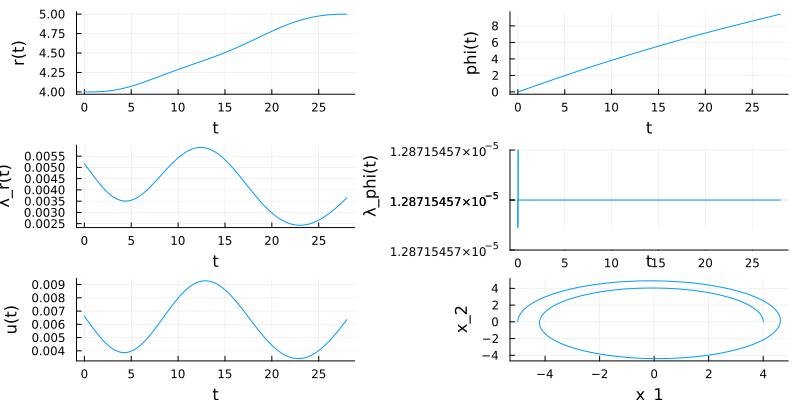

GKS: Possible loss of precision in routine SET_WINDOW


In [9]:
p1_num = plot(t, u_num,  xlabel = "t", ylabel = "u(t)",   legend = false, fmt = :png, linetype=:steppre)  
p2_num = plot(t, x[1,:], xlabel = "t", ylabel = "r(t)", legend = false, fmt = :png, linetype=:steppre)  
p3_num = plot(t, x[2,:], xlabel = "t", ylabel = "phi(t)", legend = false, fmt = :png, linetype=:steppre)  
p4_num = plot(t, λ[1,:], xlabel = "t", ylabel = "λ_r(t)", legend = false, fmt = :png, linetype=:steppre)  
p5_num = plot(t, λ[2,:], xlabel = "t", ylabel = "λ_phi(t)", legend = false, fmt = :png, linetype=:steppre)  
p6_num = plot(x1,x2,  xlabel = "x_1", ylabel = "x_2",   legend = false, fmt = :png, linetype=:steppre)  


display(plot(p2_num, p3_num, p4_num, p5_num,p1_num,p6_num, layout = (3,2), size=(800,400)))

In [10]:
X = Dict("state_r" => x[1,:],
                "state_phi" => x[2,:],
                "state_vr" => x[3,:],
                "state_vphi" => x[4,:],
                "costate_r" => λ[1,:],
                "costate_phi" => λ[2,:],
                "costate_vr" => λ[3,:],
                "costate_vphi" => λ[4,:],
                "time" => t,
                "Hamiltonian" => H_num, 
                "control" => u_num)

store("./reference_polar_corrected.pkl", X)